## Control 2 - Técnicas Computacionales para Radio Interferometría Astronómica

Autores: Juan Pablo Cárdenas - Vicente Mieres

4 de Diciembre de 2025

In [3]:
# imports
import numpy as np
import cupy as cp
import time
import dask.array as da
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
from numba import jit, prange
from numba import cuda
import math


## Pregunta 1

1.a Simule un conjunto de visibilidades sintéticas griddeadas en el espacio uv. Las visibilidades griddeadas tienen forma de matriz Nu × Nv × T , donde Nu y Nv son las dimensiones de la grilla uv y T es el número de tiempos de integración. Cree un array de Dask de tamaño 1000 × 1000 × 100 (representando visibilidades griddeadas en una grilla uv de 1000 × 1000 píxeles para 100 tiempos de integración) particionado en bloques de 200 × 200 × 20. Calcule el promedio temporal de las visibilidades usando compute().

In [1]:
def pregunta_1a():
    print("--- Pregunta 1a: Dask Distributed ---")

    cluster = LocalCluster() 
    client = Client(cluster)
    
    print(f"Dashboard disponible en: {client.dashboard_link}")
    
    try:
        # Parámetros
        Nu, Nv = 1000, 1000
        T = 100
        shape = (Nu, Nv, T)       
        chunks = (200, 200, 20)   
        print(f"Creando Dask Array de tamaño {shape} con chunks {chunks}...")

        # Visibilidades
        visibilities = (da.random.standard_normal(shape, chunks=chunks) + 
                        1j * da.random.standard_normal(shape, chunks=chunks))
        
        # Promedio
        mean_operation = visibilities.mean(axis=2)
        
        print("Iniciando cómputo distribuido...")
        start_time = time.time()
        
        temporal_mean = mean_operation.compute()
        
        end_time = time.time()
        
        print(f"Cómputo finalizado en {end_time - start_time:.4f} segundos.")
        print(f"Shape final: {temporal_mean.shape}")
        print(f"Dtype: {temporal_mean.dtype}")

        return temporal_mean

    finally:
        print('Cerrando Clúster')
        client.close()
        cluster.close()

In [4]:
res = pregunta_1a()

--- Pregunta 1a: Dask Distributed ---
Dashboard disponible en: http://127.0.0.1:8787/status
Creando Dask Array de tamaño (1000, 1000, 100) con chunks (200, 200, 20)...
Iniciando cómputo distribuido...
Cómputo finalizado en 1.1729 segundos.
Shape final: (1000, 1000)
Dtype: complex128
Cerrando Clúster


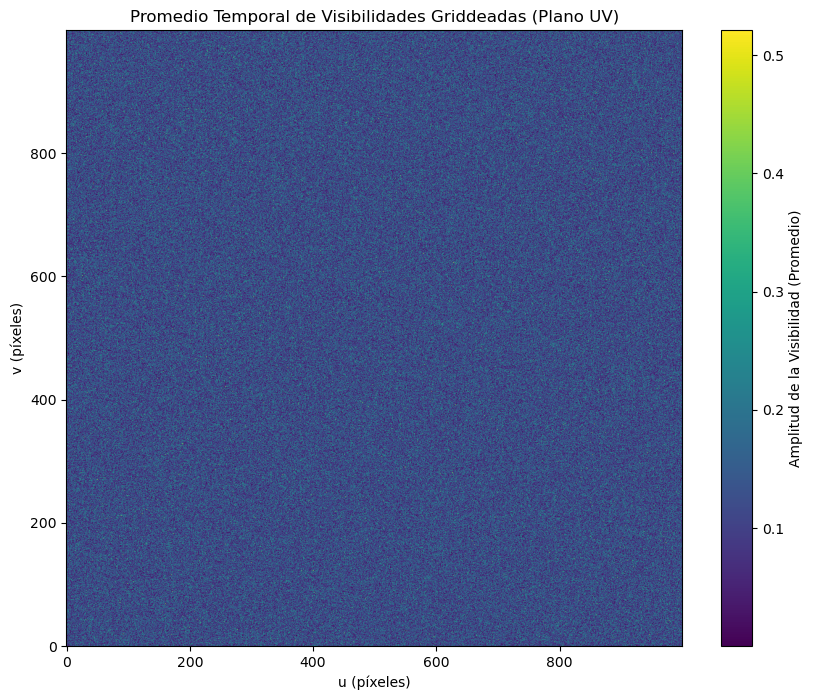

In [5]:
amplitud = np.abs(res)

# 3. Graficar
plt.figure(figsize=(10, 8))
plt.imshow(amplitud, cmap='viridis', origin='lower') # origin='lower' es estándar para coordenadas UV
plt.colorbar(label='Amplitud de la Visibilidad (Promedio)')
plt.title('Promedio Temporal de Visibilidades Griddeadas (Plano UV)')
plt.xlabel('u (píxeles)')
plt.ylabel('v (píxeles)')
plt.show()

1.b Cree 50 imágenes sintéticas de síntesis de apertura (arrays numpy complejos
de tamaño 4096 × 4096), donde cada imagen corresponde a una época de observación diferente. Implemente una función que use Dask para procesar en paralelo este conjunto de imágenes. La función debe calcular el promedio temporal de las imágenes y aplicar una transformación logarítmica al módulo del resultado (log(1 + |promedio|)). Retorne el resultado como un array de Dask y muestre cómo ejecutar el cómputo eficientemente.

In [7]:
def pregunta_1b():
    print("--- Pregunta 1b: Procesamiento de Imágenes de Síntesis ---")
    
    cluster = LocalCluster() 
    client = Client(cluster)
    print(f"Dashboard disponible en: {client.dashboard_link}")
    
    try:
        # Parámetros
        N_epochs = 50           
        IMG_SIZE = 4096         
        chunks = (1, 1024, 1024) 
        
        print(f"Generando stack de {N_epochs} imágenes de {IMG_SIZE}x{IMG_SIZE} (Lazy)...")
        
        image_stack = (da.random.standard_normal((N_epochs, IMG_SIZE, IMG_SIZE), chunks=chunks) + 
                       1j * da.random.standard_normal((N_epochs, IMG_SIZE, IMG_SIZE), chunks=chunks))
        
        print(f"Tamaño total del array en memoria: {image_stack.nbytes / 1e9:.2f} GB")

        # Cálculo del promedio
        def procesar_stack(stack_dask):            
            avg_image = stack_dask.mean(axis=0)
            mod_avg = da.absolute(avg_image)
            processed = da.log1p(mod_avg)
            return processed
        
        resultado_lazy = procesar_stack(image_stack)
        
        print("Iniciando cómputo distribuido eficiente...")
        start_time = time.time()
        
        # Compute
        imagen_final = resultado_lazy.compute()
        
        end_time = time.time()
        
        print(f"Procesamiento finalizado en {end_time - start_time:.4f} segundos.")
        print(f"Forma final: {imagen_final.shape}")
        
        return imagen_final

    finally:
        print('Cerrando Clúster')
        client.close()
        cluster.close()

--- Pregunta 1b: Procesamiento de Imágenes de Síntesis ---
Dashboard disponible en: http://127.0.0.1:8787/status
Generando stack de 50 imágenes de 4096x4096 (Lazy)...
Tamaño total del array en memoria: 13.42 GB
Iniciando cómputo distribuido eficiente...
Procesamiento finalizado en 12.3848 segundos.
Forma final: (4096, 4096)
Cerrando Clúster


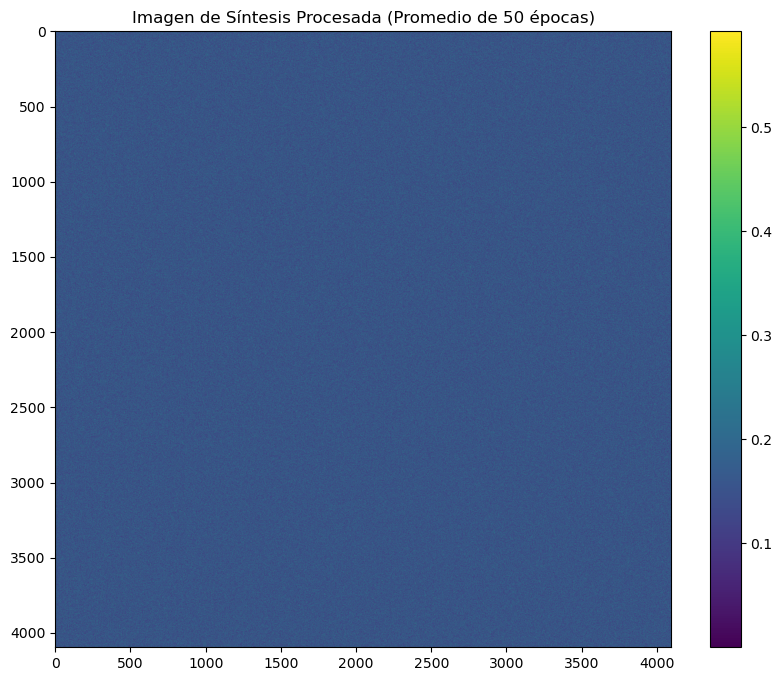

In [8]:
res = pregunta_1b()

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis')
plt.colorbar()
plt.title("Imagen de Síntesis Procesada (Promedio de 50 épocas)")
plt.show()

## Pregunta 2

En radio interferometría, la función de correlación cruzada entre dos conjuntos de
visibilidades griddeadas es útil para analizar variabilidad temporal o entre frecuencias. Implemente una función usando Numba CPU (@numba.jit) que calcule la correlación cruzada 2D entre dos matrices de visibilidades griddeadas complejas. Dadas dos matrices de visibilidades V1 y V2 de tamaño N ×N (donde cada elemento es un número complejo), la función debe calcular la correlación cruzada con condiciones de frontera periódicas. (Fórmula aquí).

donde z denota el conjugado complejo y el módulo asegura condiciones de frontera periódicas. La función debe retornar una matriz compleja de tamaño N × N y estar optimizada con Numba. Para probar la función, simule dos conjuntos de visibilidades sintéticas griddeadas de tamaño N × N.

In [8]:
def simular_visibilidades(N):
    # Generamos parte real e imaginaria aleatoria
    real_part = np.random.randn(N, N)
    imag_part = np.random.randn(N, N)
    # Retornamos el array complejo
    return real_part + 1j * imag_part

@jit(nopython=True, parallel=True, fastmath=True)
def correlacion_cruzada_cpu(V1, V2):
    N = V1.shape[0]
    C = np.zeros((N, N), dtype=np.complex128)
    V2c = V2.conjugate()

    for i in prange(N):
        for j in range(N):
            acc_real = 0.0
            acc_imag = 0.0
            for x in range(N):
                x2 = (x + i) % N
                for y in range(N):

                    y2 = (y + j) % N

                    a = V1[x, y]
                    b = V2c[x2, y2]
                    acc_real += (a.real * b.real - a.imag * b.imag)
                    acc_imag += (a.real * b.imag + a.imag * b.real)

            C[i, j] = acc_real + 1j * acc_imag

    return C

def correlacion_cupy_fft(V1_host, V2_host):
    d_V1 = cp.asarray(V1_host)
    d_V2 = cp.asarray(V2_host)

    cp.cuda.Stream.null.synchronize()
    start = time.time()

    F_V1 = cp.fft.fft2(d_V1)
    F_V2_conj = cp.fft.fft2(d_V2.conj())
    F_C = F_V1.conj() * F_V2_conj

    d_C = cp.fft.ifft2(F_C)

    cp.cuda.Stream.null.synchronize()
    end = time.time()

    return d_C.get(), end - start

In [14]:
# Código CPU
N = 256
V1 = simular_visibilidades(N)
V2 = simular_visibilidades(N)

print(f"Iniciando cálculo CPU con N={N}...")
start_time = time.time()

resultado = correlacion_cruzada_cpu(V1, V2)

end_time = time.time()
print(f"Tiempo de ejecución (incluyendo compilación): {end_time - start_time:.4f} segundos")

start_time = time.time()
resultado = correlacion_cruzada_cpu(V1, V2)
end_time = time.time()
print(f"Tiempo de ejecución (compilado): {end_time - start_time:.4f} segundos")

Iniciando cálculo CPU con N=256...
Tiempo de ejecución (incluyendo compilación): 1.9475 segundos
Tiempo de ejecución (compilado): 1.1365 segundos


In [15]:
# Codigo GPU
N = 2048
print(f"Generando datos {N}x{N}...")
V1 = (np.random.randn(N, N) + 1j * np.random.randn(N, N)).astype(np.complex128)
V2 = (np.random.randn(N, N) + 1j * np.random.randn(N, N)).astype(np.complex128)

print("Ejecutando CuPy FFT...")
resultado, tiempo = correlacion_cupy_fft(V1, V2)
print(f"Tiempo CuPy FFT: {tiempo:.6f} segundos")

Generando datos 2048x2048...
Ejecutando CuPy FFT...
Tiempo CuPy FFT: 0.009912 segundos


## Pregunta 3

3.a En el contexto de procesamiento de visibilidades griddeadas en radio interferometría, frecuentemente necesitamos realizar operaciones matriciales sobre grandes volúmenes de datos. Simule dos conjuntos de visibilidades sintéticas griddeadas (arrays complejos de CuPy de tamaño 4096 × 4096) y calcule su producto matricial usando CuPy. Esta operación puede ser útil en algoritmos de deconvolución o en el procesamiento de datos multi-frecuencia. Muestre el tiempo de ejecución.

In [17]:
def pregunta_3a():
    print("--- Pregunta 3a: Operaciones Matriciales con CuPy ---")
    
    # DAtos
    N = 4096
    print(f"Simulando dos matrices complejas de {N}x{N} en GPU")
    
    cp.cuda.Stream.null.synchronize()
    
    mat_A = cp.random.random((N, N)) + 1j * cp.random.random((N, N))
    mat_B = cp.random.random((N, N)) + 1j * cp.random.random((N, N))
    
    print(f"Memoria utilizada por matriz: {mat_A.nbytes / 1e9:.2f} GB")
    
    cp.cuda.Stream.null.synchronize()
    start_time = time.time()
    # Producto matricial
    resultado = mat_A @ mat_B
    cp.cuda.Stream.null.synchronize()
    
    end_time = time.time()
    
    print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")
    print(f"Forma del resultado: {resultado.shape}")
    
    del mat_A, mat_B, resultado
    cp.get_default_memory_pool().free_all_blocks()
    print("Memoria GPU liberada.")

In [18]:
pregunta_3a()

--- Pregunta 3a: Operaciones Matriciales con CuPy ---
Simulando dos matrices complejas de 4096x4096 en GPU
Memoria utilizada por matriz: 0.27 GB
Tiempo de ejecución: 1.8666 segundos
Forma del resultado: (4096, 4096)
Memoria GPU liberada.


3.b Cree una imagen sintética de síntesis de apertura (array complejo de tamaño
8192 × 8192). Implemente una función que use CuPy para aplicar una transformada de Fourier 2D a esta imagen, luego multiplique el resultado en el espacio de frecuencias por un filtro de ventana gaussiana (para suavizar el ruido) y finalmente aplique la transformada inversa para obtener la imagen filtrada. Compare el tiempo de ejecución con la versión equivalente usando NumPy y discuta la importancia de la aceleración por GPU para el procesamiento de grandes imágenes de radio interferometría.

In [19]:
def crear_filtro_gaussiano(N, sigma, xp):
    """
    Crea un filtro gaussiano 2D centrado.
    """
    x = xp.arange(-N // 2, N // 2)
    y = xp.arange(-N // 2, N // 2)
    X, Y = xp.meshgrid(x, y)
    
    filtro = xp.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return filtro

def procesamiento_cupy(N, sigma):
    print(f"--- CuPy (GPU) N={N} ---")
    
    cp.cuda.Stream.null.synchronize()
    
    img_gpu = cp.random.random((N, N)).astype(cp.complex64)
    filtro_gpu = crear_filtro_gaussiano(N, sigma, cp).astype(cp.complex64)
    
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    
    # 2. FFT 2D
    freq_domain = cp.fft.fftshift(cp.fft.fft2(cp.fft.ifftshift(img_gpu)))
    
    # Filtro
    filtered_freq = freq_domain * filtro_gpu
    
    # IFFT 2D
    img_filtrada = cp.fft.fftshift(cp.fft.ifft2(cp.fft.ifftshift(filtered_freq)))
    
    cp.cuda.Stream.null.synchronize()
    end = time.time()
    
    tiempo = end - start
    print(f"Tiempo GPU: {tiempo:.4f} s")
    return tiempo

def procesamiento_numpy(N, sigma):
    print(f"--- NumPy (CPU) N={N} ---")
    
    img_cpu = np.random.random((N, N)).astype(np.complex64)
    filtro_cpu = crear_filtro_gaussiano(N, sigma, np).astype(np.complex64)
    
    start = time.time()
    
    # 2. FFT 2D
    freq_domain = np.fft.fftshift(np.fft.fft2(img_cpu))
    
    # 3. Aplicar Filtro
    filtered_freq = freq_domain * filtro_cpu
    
    # 4. IFFT 2D
    img_filtrada = np.fft.ifft2(np.fft.ifftshift(filtered_freq))
    
    end = time.time()
    
    tiempo = end - start
    print(f"Tiempo CPU: {tiempo:.4f} s")
    return tiempo

def pregunta_3b():
    print("Comparando tiempos de procesamiento de imágenes...")
    
    # Parámetros del enunciado
    N = 8192      
    sigma = 500   
    try:
        t_gpu = procesamiento_cupy(N, sigma)
        t_cpu = procesamiento_numpy(N, sigma)
        
        print("\n--- Resultados ---")
        print(f"Aceleración (Speedup): {t_cpu / t_gpu:.2f}x más rápido en GPU")
        
    except cp.cuda.memory.OutOfMemoryError:
        print("Error: No hay suficiente VRAM en la GPU para 8192x8192 complex128.")
        print("Prueba bajando a 'complex64' o reduciendo N si tu GPU tiene < 4GB VRAM.")


In [20]:
pregunta_3b()

Comparando tiempos de procesamiento de imágenes...
--- CuPy (GPU) N=8192 ---
Tiempo GPU: 0.0495 s
--- NumPy (CPU) N=8192 ---
Tiempo CPU: 5.9003 s

--- Resultados ---
Aceleración (Speedup): 119.28x más rápido en GPU


Discusión: Se obtuvo una aceleración de ~119x (0.05s en GPU vs 5.9s en CPU) . Esto demuestra la superioridad de la GPU para tareas altamente paralelizables como la FFT, donde miles de núcleos procesan la imagen simultáneamente. En radiointerferometría, esta eficiencia es crítica para algoritmos iterativos de deconvolución (como CLEAN), reduciendo tiempos de cálculo de horas a minutos y haciendo viable el procesamiento de datos de alta resolución de telescopios modernos.

## Pregunta 4

4.a Escriba una función que calcule el ruido RMS (root mean square) de un conjunto de visibilidades complejas (array numpy complejo). El ruido RMS se calcula como el promedio de los RMS de las partes real e imaginaria: RMS = 0,5 × (RMS(real) + RMS(imag)), donde RMS corresponde a la desviación estándar. Cree al menos 3 tests usando pytest que verifiquen diferentes casos: simule visibilidades sintéticas no griddeadas con ruido gaussiano, visibilidades con un solo valor, y visibilidades vacías (debe lanzar una excepción apropiada).

In [10]:
!pytest rms_testing.py -v

]9;4;3;\============================= test session starts ==============================
platform linux -- Python 3.13.7, pytest-9.0.1, pluggy-1.6.0 -- /home/vcnt/y/envs/lab2_env/bin/python3.13
cachedir: .pytest_cache
rootdir: /home/vcnt/Repositories/RadioInterferometry/control2
plugins: anyio-4.12.0
collected 3 items                                                              

rms_testing.py::test_rms_ruido_gaussiano ]9;4;1;0\PASSED                          [ 33%]
rms_testing.py::test_rms_un_solo_valor ]9;4;1;33\PASSED                            [ 66%]
rms_testing.py::test_rms_array_vacio ]9;4;1;66\PASSED                              [100%]]9;4;0;\

============================== 3 passed in 0.04s ===============================


4.b Cree un test parametrizado usando @pytest.mark.parametrize que pruebe la función de ruido RMS. Para cada test, simule visibilidades sintéticas no griddeadas con diferentes números de elementos (100, 1000, 10000) y diferentes niveles de ruido. Verifique que el ruido RMS calculado esté dentro de un rango esperado dado el nivel de ruido simulado.


In [13]:
!pytest rms_testing_2_verif.py -v

]9;4;3;\============================= test session starts ==============================
platform linux -- Python 3.13.7, pytest-9.0.1, pluggy-1.6.0 -- /home/vcnt/y/envs/lab2_env/bin/python3.13
cachedir: .pytest_cache
rootdir: /home/vcnt/Repositories/RadioInterferometry/control2
plugins: anyio-4.12.0
collected 5 items                                                              

rms_testing_2_verif.py::test_rms_parametrizado[100-0.5] ]9;4;1;0\PASSED           [ 20%]
rms_testing_2_verif.py::test_rms_parametrizado[100-2.0] ]9;4;1;20\PASSED           [ 40%]
rms_testing_2_verif.py::test_rms_parametrizado[1000-1.0] ]9;4;1;40\PASSED          [ 60%]
rms_testing_2_verif.py::test_rms_parametrizado[10000-0.1] ]9;4;1;60\PASSED         [ 80%]
rms_testing_2_verif.py::test_rms_parametrizado[10000-5.0] ]9;4;1;80\PASSED         [100%]]9;4;0;\

============================== 5 passed in 0.04s ===============================
